# Batch Results Insights
Load a batch report by name and generate diagnostics + metric insights across perturbation types.


In [26]:
import sys
from pathlib import Path

import pandas as pd

if (Path.cwd() / 'Batch_Analysis').exists():
    from Batch_Analysis import (
        get_repo_and_outputs_root,
        find_report_files,
        load_batch_dataframe,
        summarize_by_family,
        compute_baseline_deltas,
        show_top_worst,
        plot_metric_bars,
        run_full_perturbation_analysis,
    )
else:
    from Notebooks.Batch_Analysis import (
        get_repo_and_outputs_root,
        find_report_files,
        load_batch_dataframe,
        summarize_by_family,
        compute_baseline_deltas,
        show_top_worst,
        plot_metric_bars,
        run_full_perturbation_analysis,
    )

REPO_ROOT, OUTPUTS_ROOT = get_repo_and_outputs_root()
pd.set_option('display.max_colwidth', 120)


In [34]:
BATCH_NAME = 'final_dcgan'  # change this
REPORT_SUFFIX = 'mnist_perturbation_tests'

report_files = find_report_files(OUTPUTS_ROOT, BATCH_NAME, REPORT_SUFFIX)
print('Reports found:', len(report_files))
for p in report_files:
    print('-', p.name)

if not report_files:
    raise FileNotFoundError(f'No reports found for BATCH_NAME={BATCH_NAME!r} under {OUTPUTS_ROOT}')


Reports found: 1
- final_dcgan_batch_dcgan_mnist_perturbation_tests.json


In [35]:
df = load_batch_dataframe(report_files)
df[['name', 'model', 'dataset', 'perturbation_family', 'status', 'metrics_available']].head(8)


Rows loaded: 11
Columns: 49


,name,model,dataset,perturbation_family,status,metrics_available
0,baseline_no_perturbation,dcgan,mnist,baseline,completed,True
1,degrade_noise_sev1,dcgan,mnist,degradation_noise,completed,True
2,degrade_noise_sev2,dcgan,mnist,degradation_noise,completed,True
3,degrade_noise_sev3,dcgan,mnist,degradation_noise,completed,True
4,degrade_noise_sev4,dcgan,mnist,degradation_noise,completed,True
5,degrade_noise_sev5,dcgan,mnist,degradation_noise,completed,True
6,degrade_blur_sev1,dcgan,mnist,degradation_blur,completed,True
7,degrade_blur_sev2,dcgan,mnist,degradation_blur,completed,True


,experiments,rows,successful_rows,with_metrics,fid_mean,is_mean,precision_mean,recall_mean
perturbation_family,,,,,,,,
degradation_blur,5,5,5,5,198.814503,1.641115,0.130469,0.108594
degradation_noise,5,5,5,5,198.625457,2.101295,0.010937,0.031250
baseline,1,1,1,1,50.728334,2.302771,0.402344,0.500000


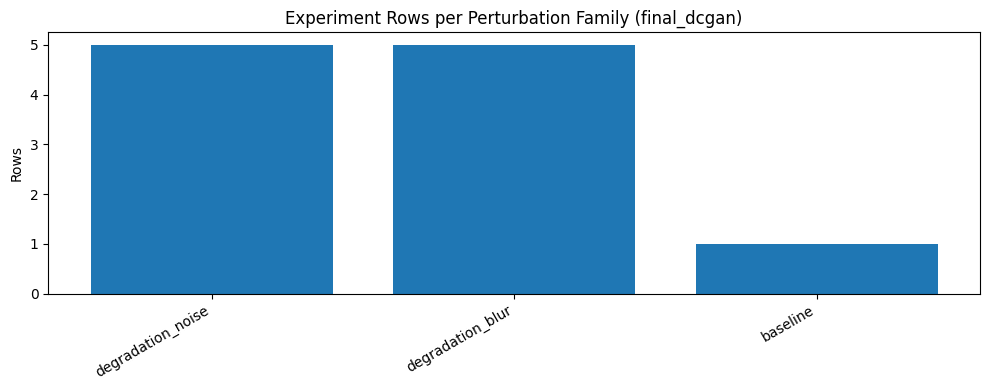

,experiments,rows,successful_rows,with_metrics,fid_mean,is_mean,precision_mean,recall_mean
perturbation_family,,,,,,,,
degradation_blur,5,5,5,5,198.814503,1.641115,0.130469,0.108594
degradation_noise,5,5,5,5,198.625457,2.101295,0.010937,0.031250
baseline,1,1,1,1,50.728334,2.302771,0.402344,0.500000


In [36]:
family_summary = summarize_by_family(df, BATCH_NAME)
family_summary


In [37]:
df_delta, delta_summary = compute_baseline_deltas(df)
delta_summary


,fid_delta,kid_mean_delta,is_mean_delta,precision_delta,recall_delta,density_delta,coverage_delta
perturbation_family,,,,,,,
baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
degradation_blur,148.086169,0.191438,-0.661656,-0.271875,-0.391406,-0.183594,-0.451562
degradation_noise,147.897122,0.195338,-0.201476,-0.391406,-0.468750,-0.283906,-0.573438


,fid_delta,kid_mean_delta,is_mean_delta,precision_delta,recall_delta,density_delta,coverage_delta
perturbation_family,,,,,,,
baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
degradation_blur,148.086169,0.191438,-0.661656,-0.271875,-0.391406,-0.183594,-0.451562
degradation_noise,147.897122,0.195338,-0.201476,-0.391406,-0.468750,-0.283906,-0.573438


In [ ]:
show_top_worst(df_delta)


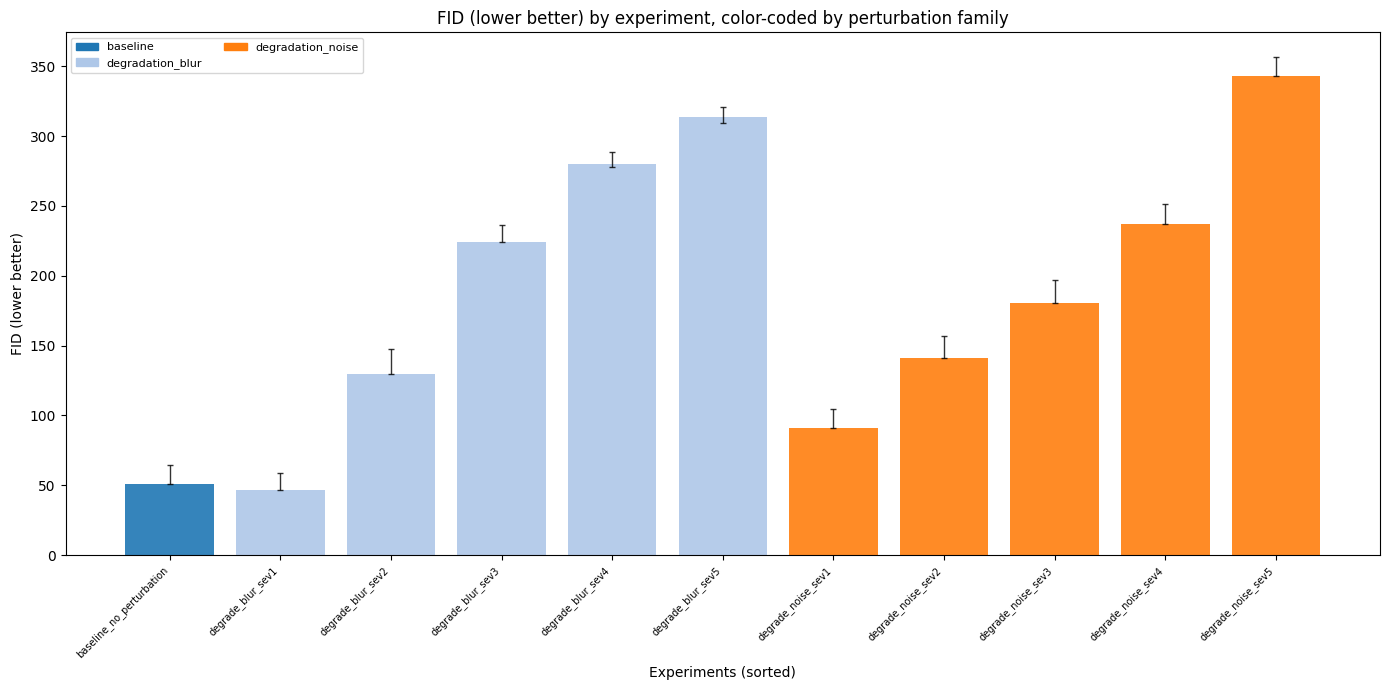

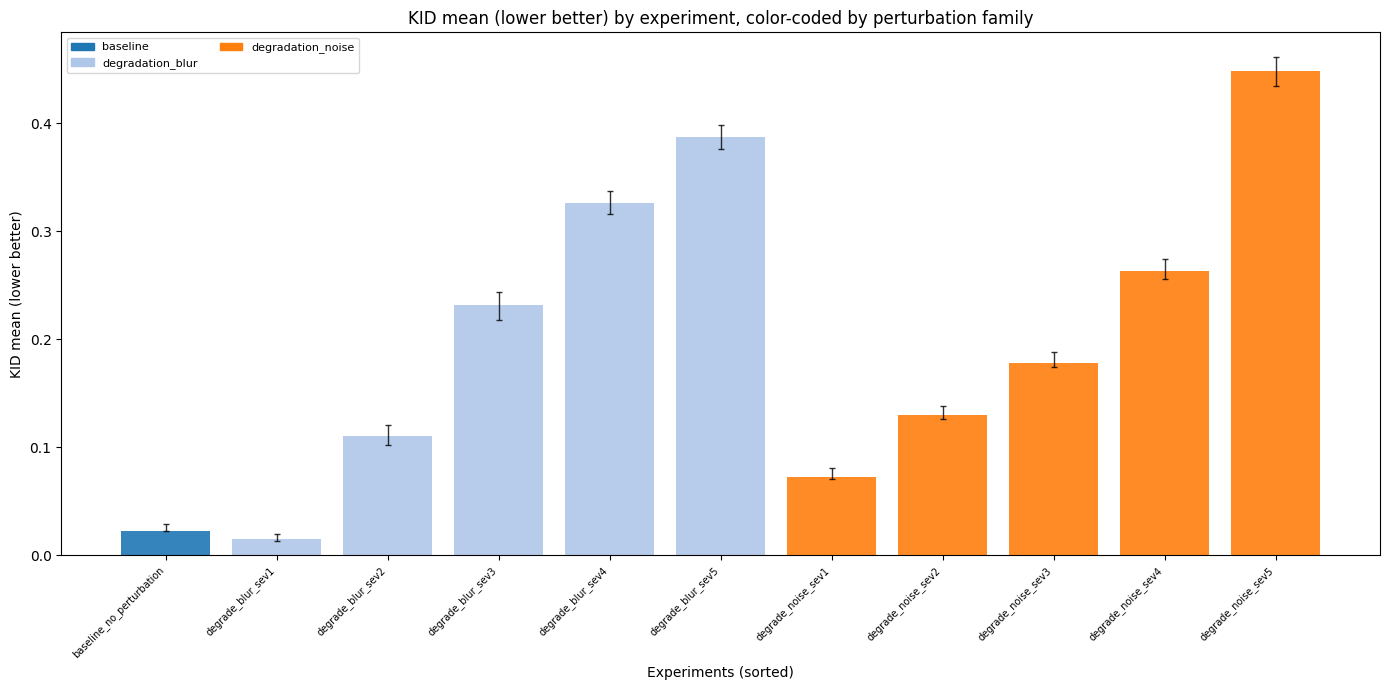

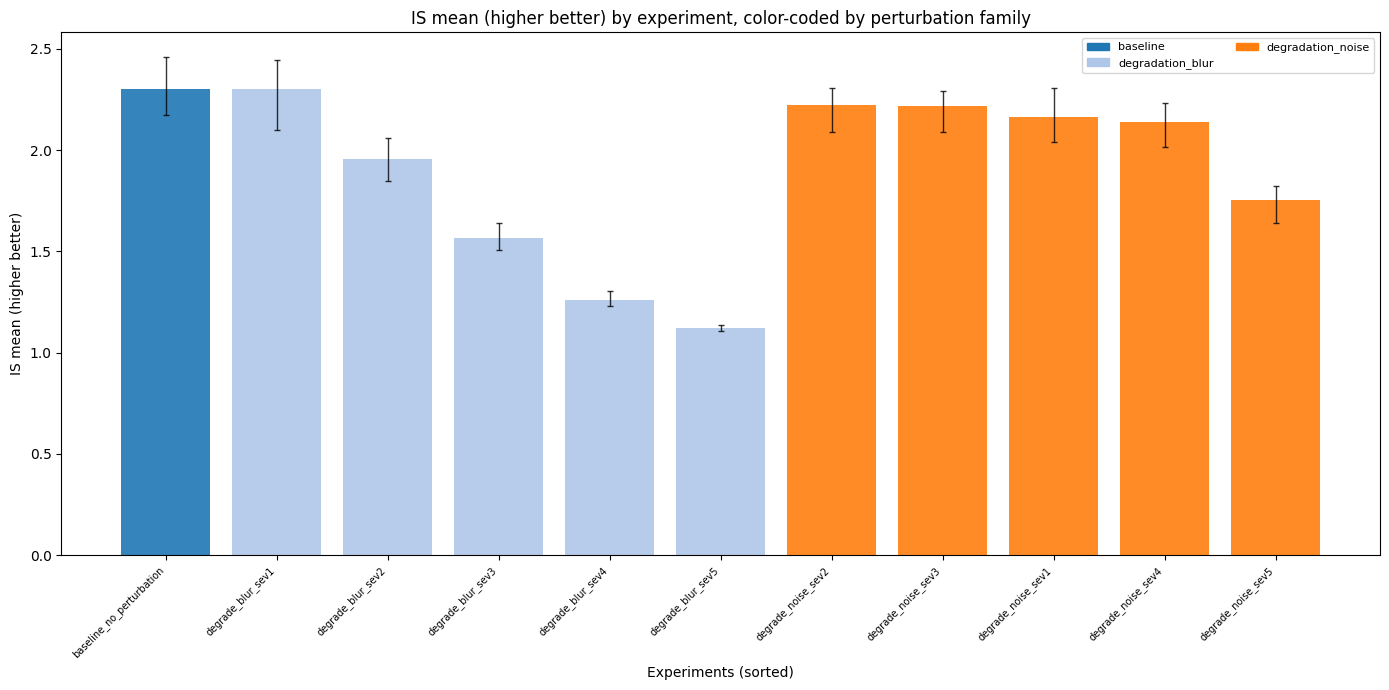

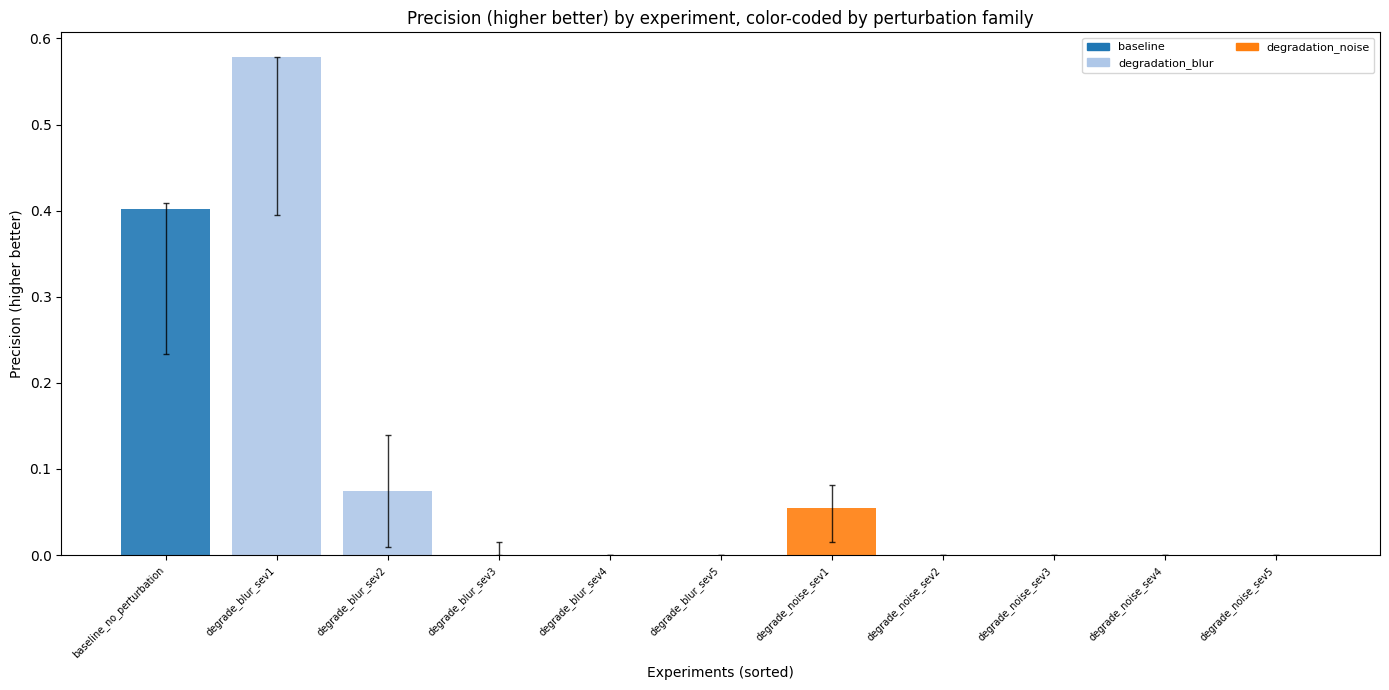

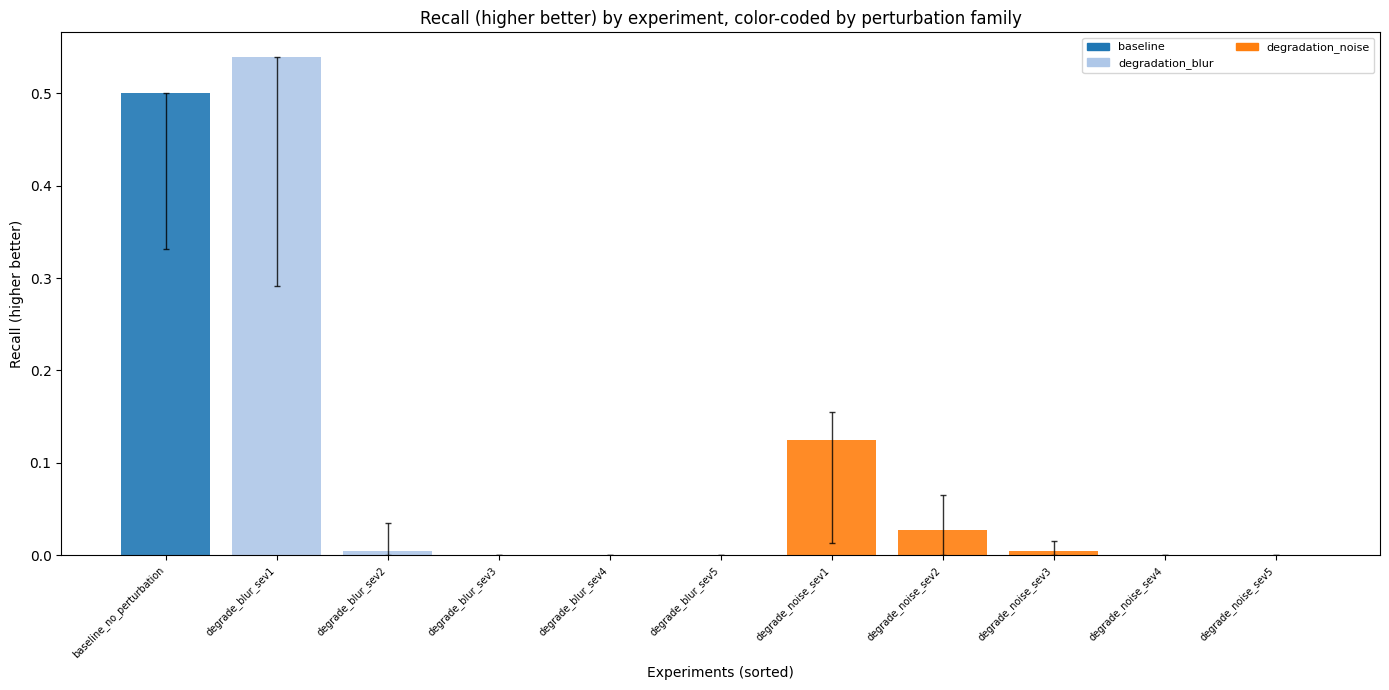

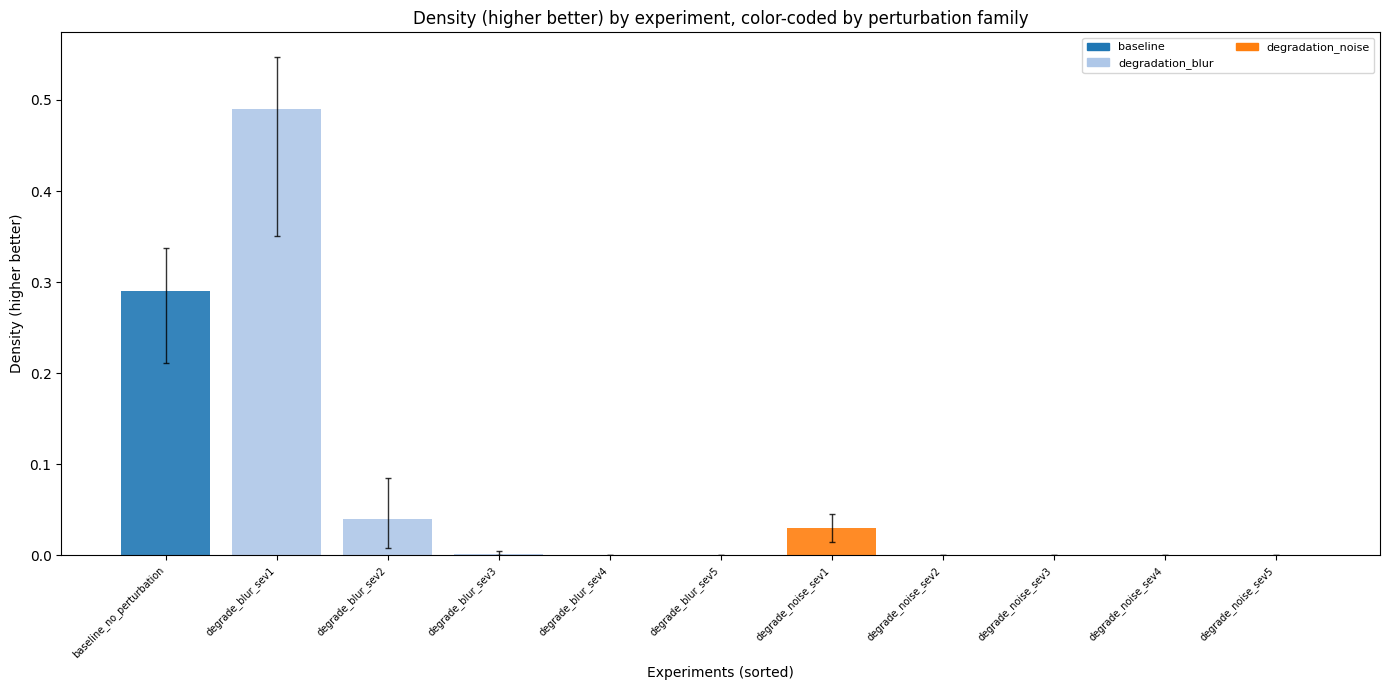

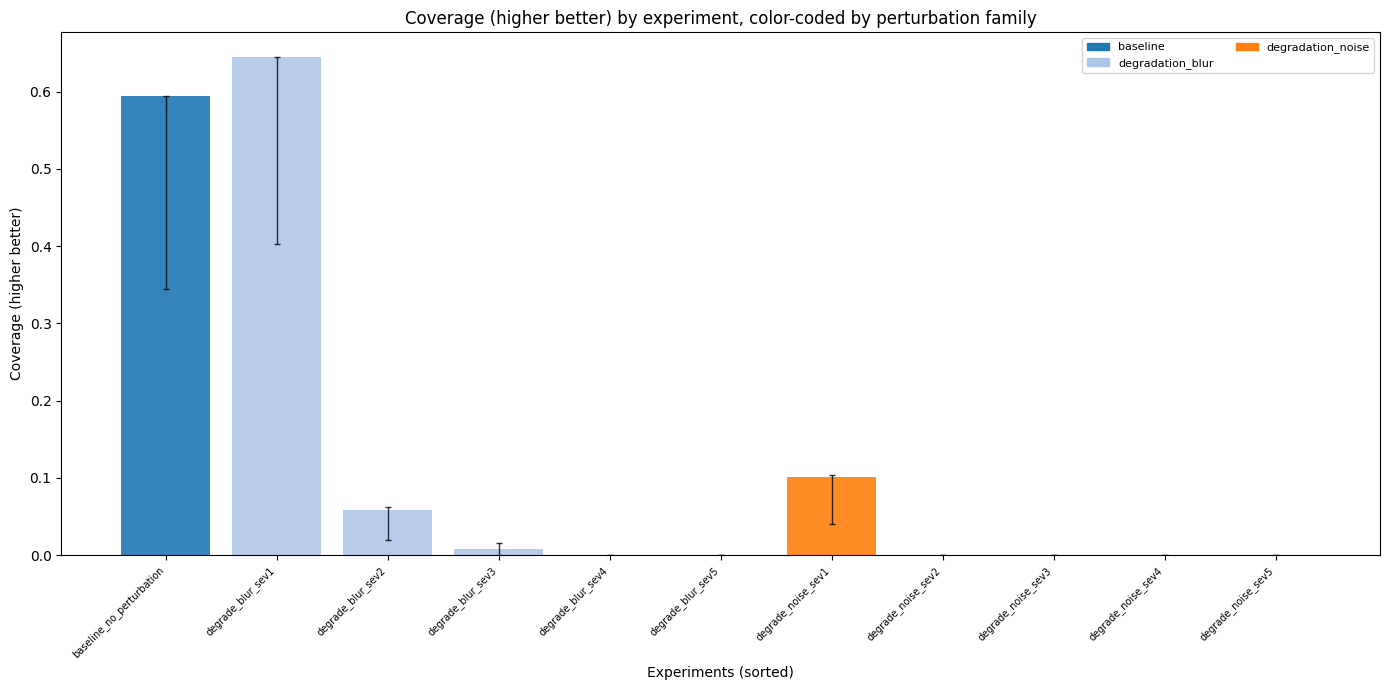

In [39]:
plot_metric_bars(df_delta)


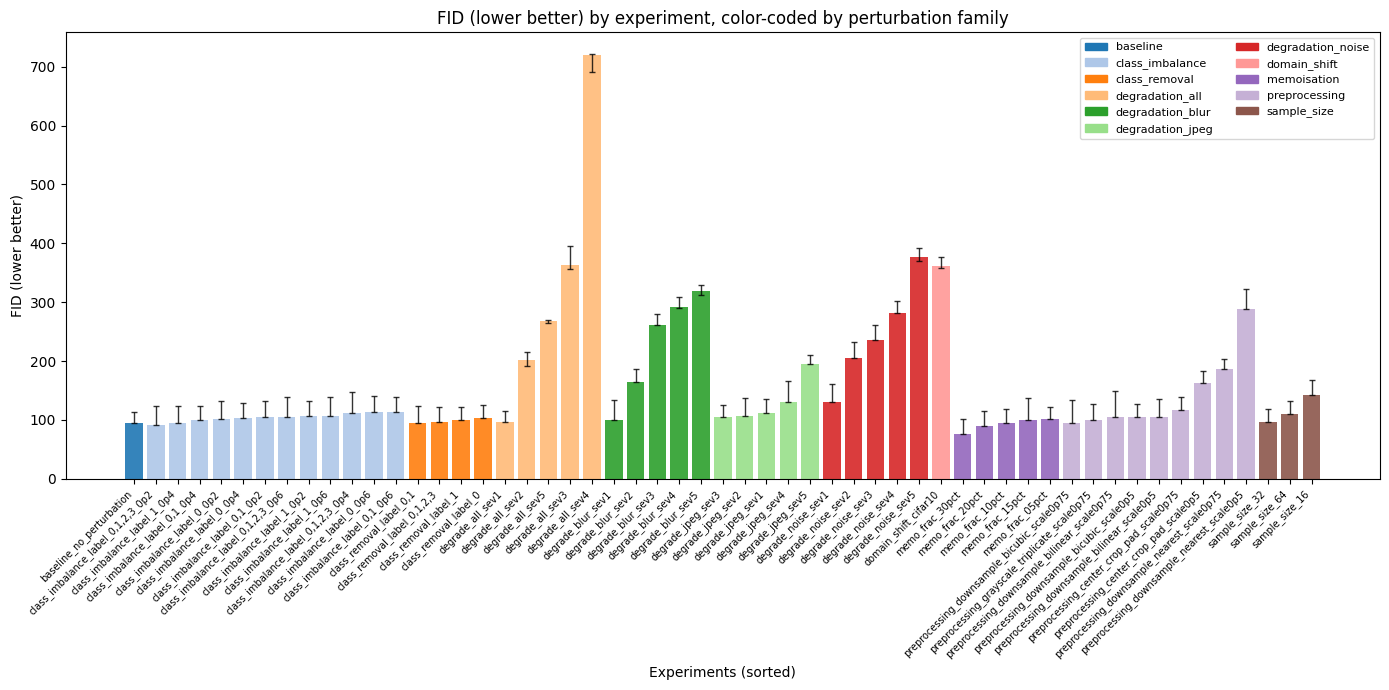

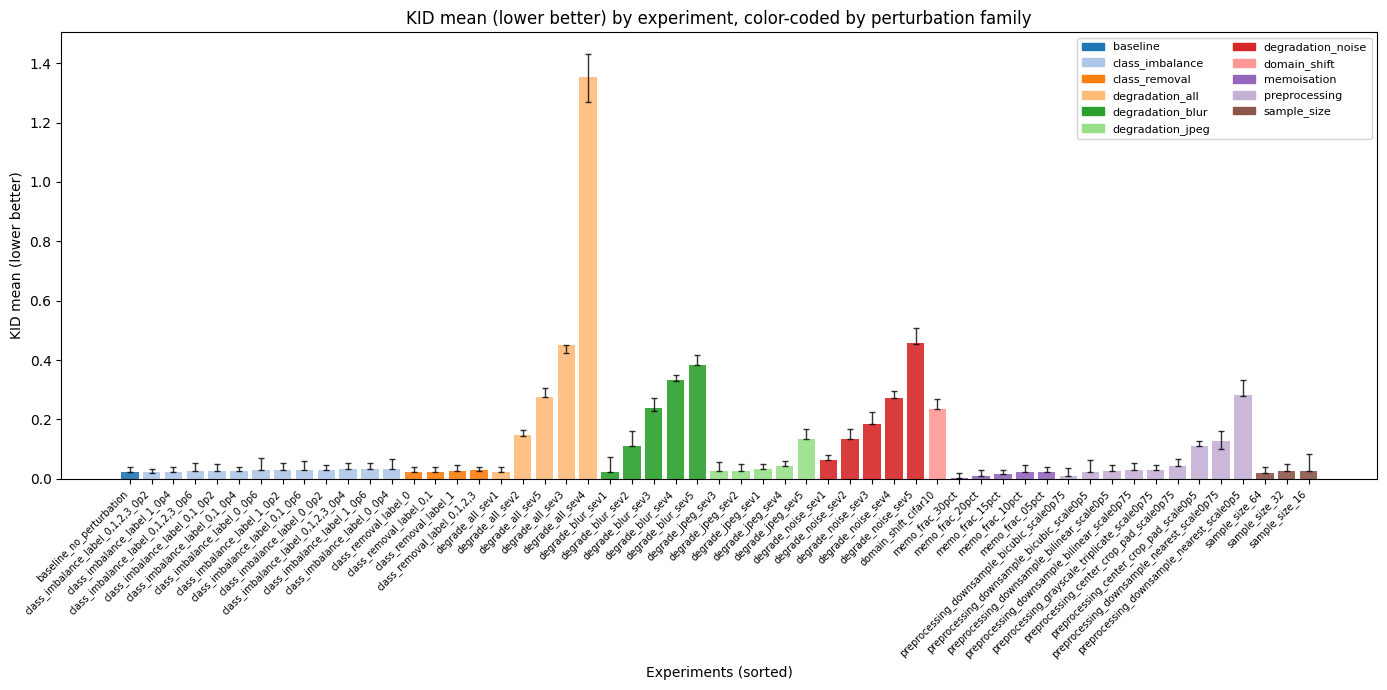

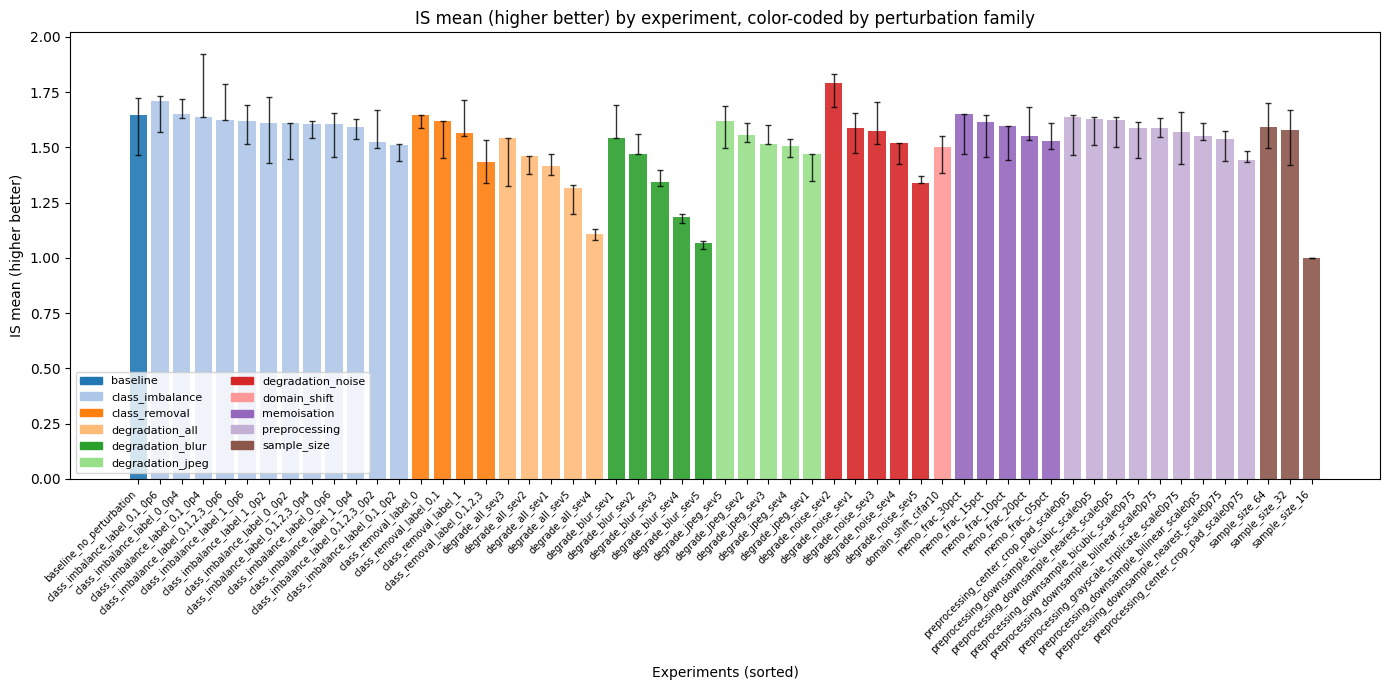

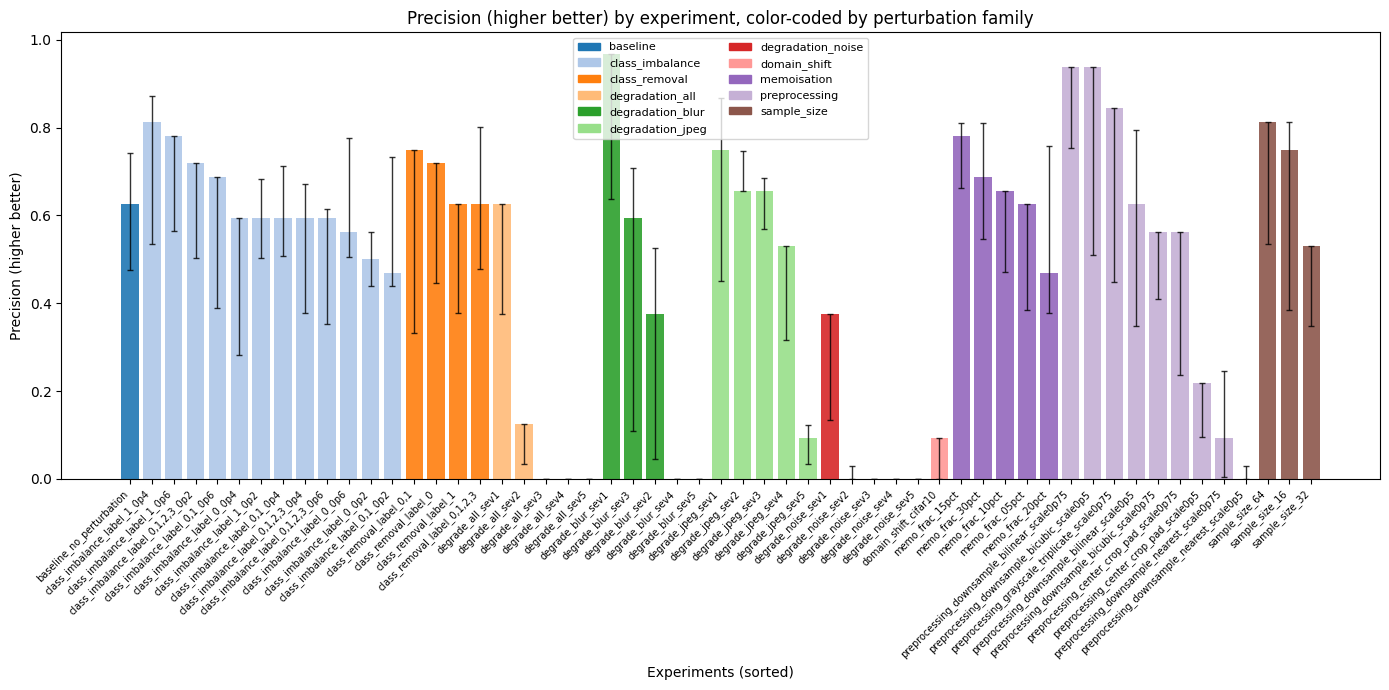

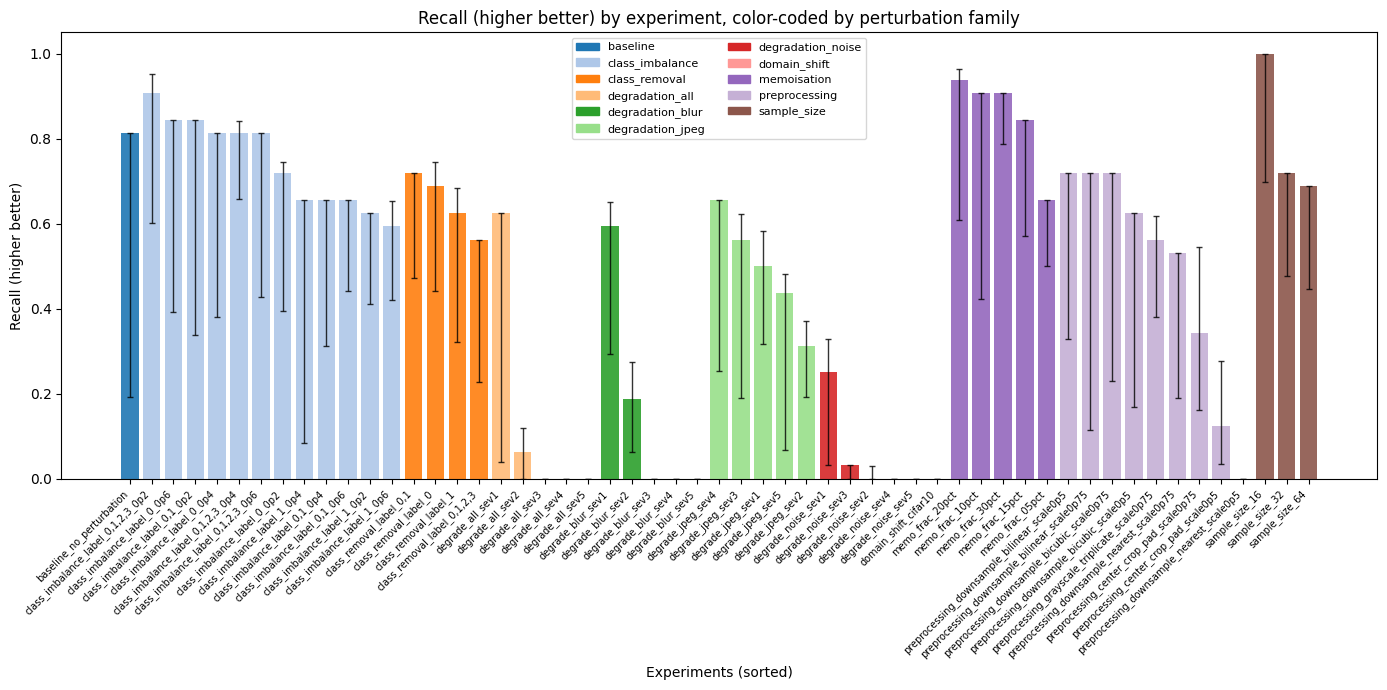

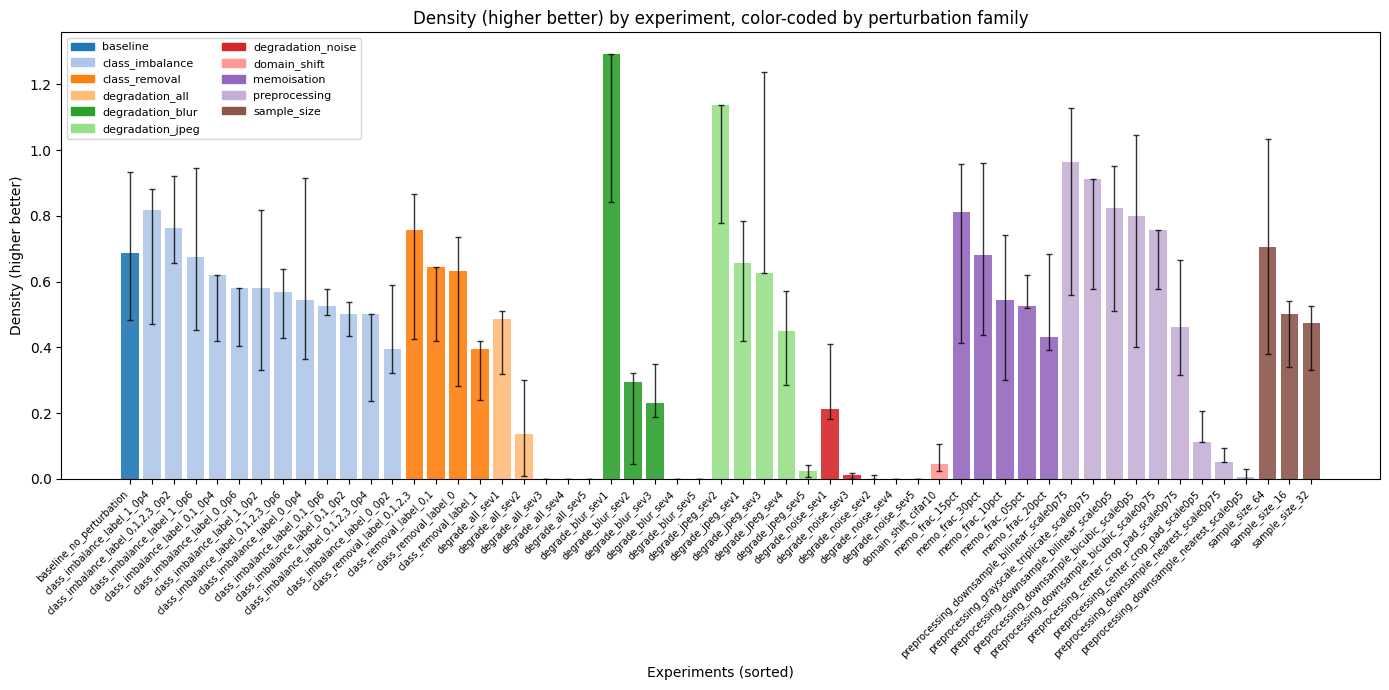

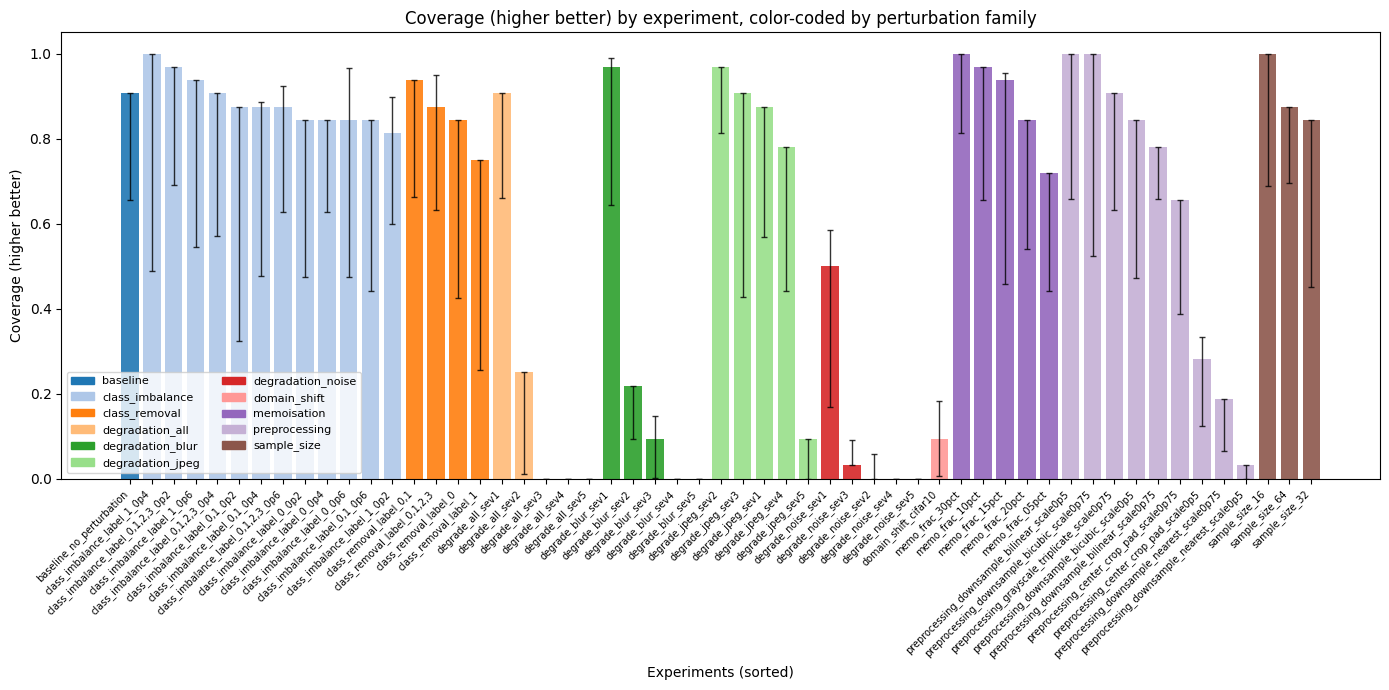

In [23]:
# Additional advanced scorecard plots are in the section below.


## Metric Scorecard Plot

Notebook version of `Scripts/metrics_performance.py` using the currently loaded `df`. It computes monotonicity (Spearman), sensitivity (max relative baseline change), robustness (CV across k-means variants), then renders the scorecard figure.


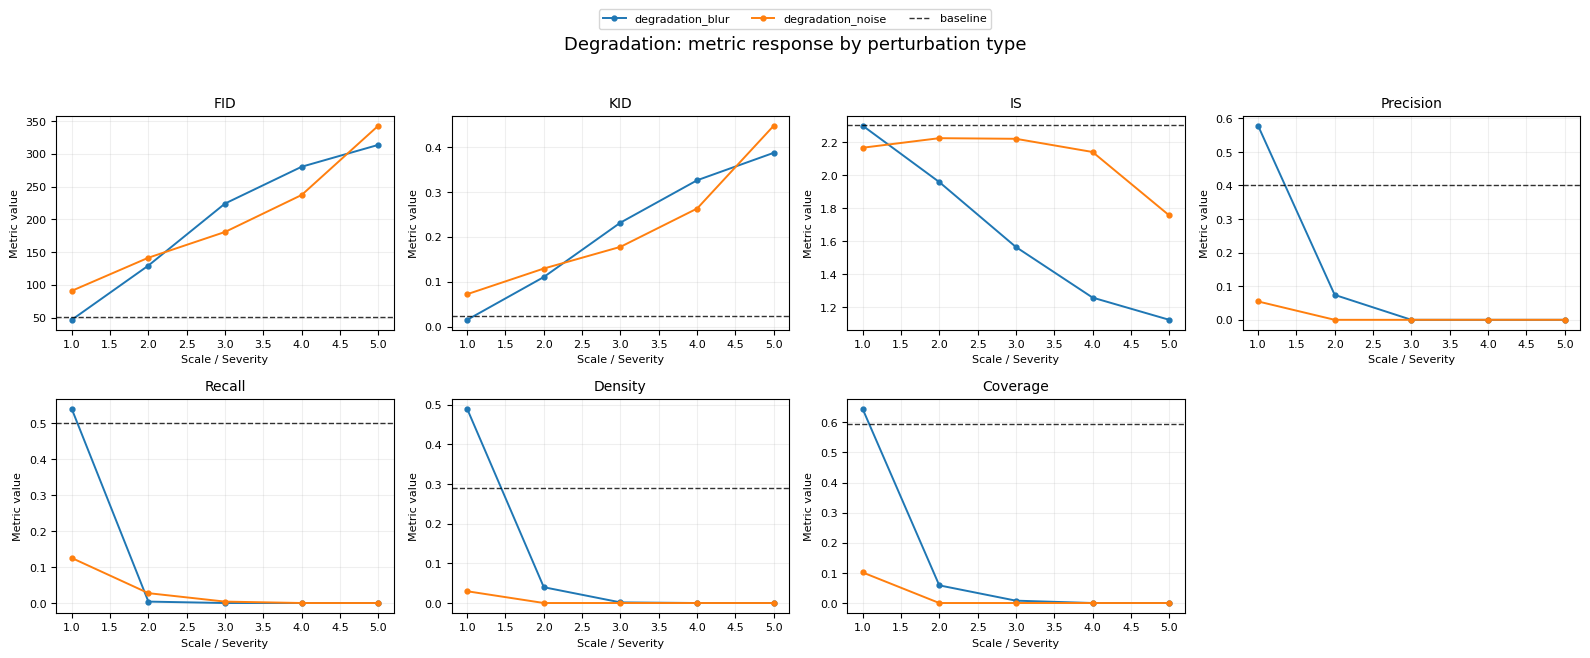

No groups to plot for: Class Removal
No groups to plot for: Class Imbalance
No groups to plot for: Memoisation
No groups to plot for: Sample Size
No groups to plot for: Preprocessing
No domain-shift rows found for dedicated plotting.


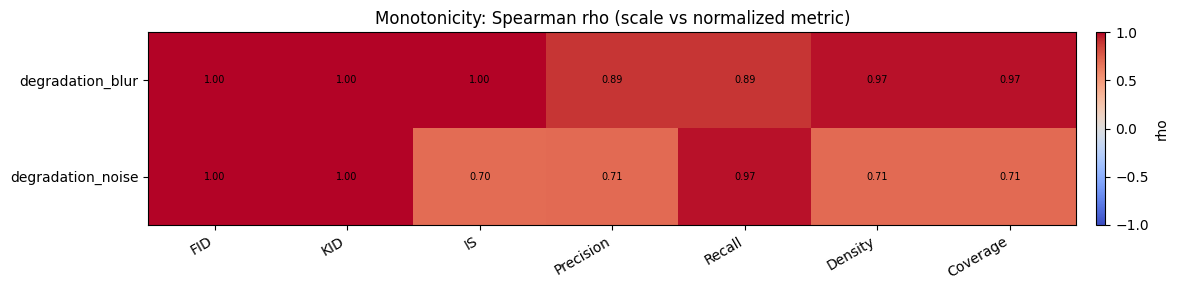

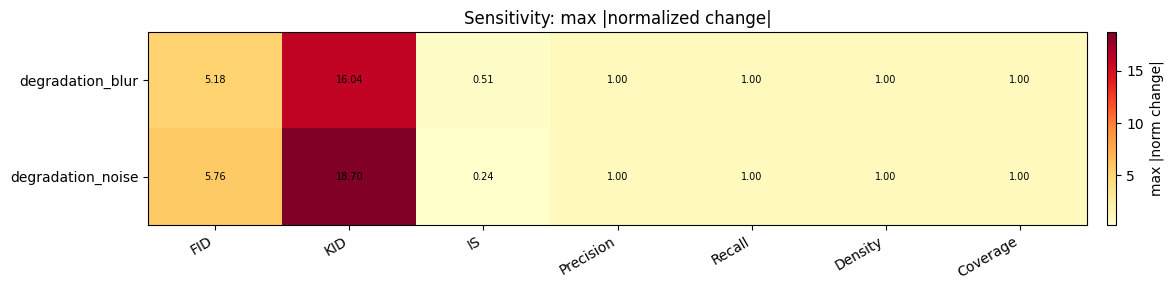

Robustness: no sample-size/preprocessing/domain-shift rows found.


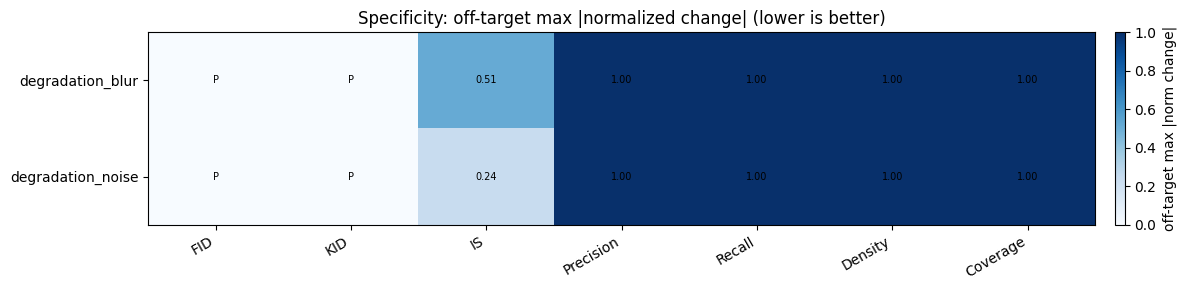

Perturbation groups included (curve analysis; domain_shift has dedicated plots):
['degradation_blur', 'degradation_noise']
Specificity NA diagnostics (P = primary metric cell):


,specificity_kind,is_na,count
0,off_target,False,10
1,primary_metric,False,4


Monotonicity (head):


,perturbation_group,metric,rho_spearman,p_value,abs_rho
6,degradation_blur,coverage,0.974679,4.818230e-03,0.974679
5,degradation_blur,density,0.974679,4.818230e-03,0.974679
0,degradation_blur,fid,1.000000,1.404265e-24,1.000000
2,degradation_blur,is_mean,1.000000,1.404265e-24,1.000000
1,degradation_blur,kid_mean,1.000000,1.404265e-24,1.000000
3,degradation_blur,precision,0.894427,4.051933e-02,0.894427
4,degradation_blur,recall,0.894427,4.051933e-02,0.894427
13,degradation_noise,coverage,0.707107,1.816901e-01,0.707107
12,degradation_noise,density,0.707107,1.816901e-01,0.707107
7,degradation_noise,fid,1.000000,1.404265e-24,1.000000


Sensitivity (head):


,perturbation_group,metric,max_abs_norm_change,mean_abs_norm_change
6,degradation_blur,coverage,1.000000,0.794737
5,degradation_blur,density,1.000000,0.909434
0,degradation_blur,fid,5.183918,2.952163
2,degradation_blur,is_mean,0.511882,0.287330
1,degradation_blur,kid_mean,16.040373,8.555360
3,degradation_blur,precision,1.000000,0.850485
4,degradation_blur,recall,1.000000,0.814063
13,degradation_noise,coverage,1.000000,0.965789
12,degradation_noise,density,1.000000,0.979515
7,degradation_noise,fid,5.762358,2.915474


Robustness (head):


""


Specificity (head):


,perturbation_group,metric,off_target_max_abs_norm,off_target_mean_abs_norm,specificity_kind
6,degradation_blur,coverage,1.000000,0.794737,off_target
5,degradation_blur,density,1.000000,0.909434,off_target
0,degradation_blur,fid,0.000000,0.000000,primary_metric
2,degradation_blur,is_mean,0.511882,0.287330,off_target
1,degradation_blur,kid_mean,0.000000,0.000000,primary_metric
3,degradation_blur,precision,1.000000,0.850485,off_target
4,degradation_blur,recall,1.000000,0.814063,off_target
13,degradation_noise,coverage,1.000000,0.965789,off_target
12,degradation_noise,density,1.000000,0.979515,off_target
7,degradation_noise,fid,0.000000,0.000000,primary_metric


In [40]:
run_full_perturbation_analysis(df)
